   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
Sh

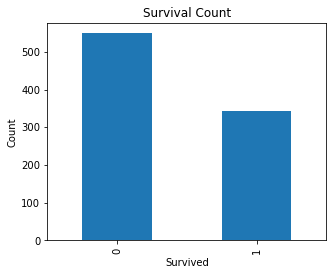

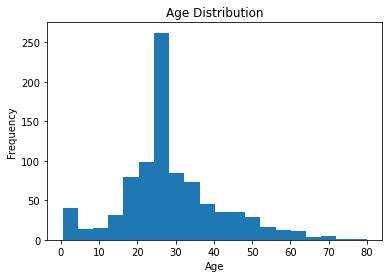

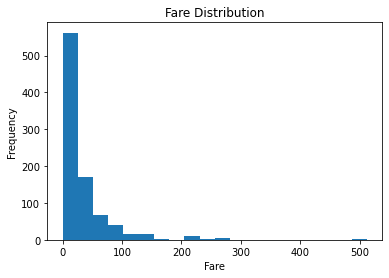

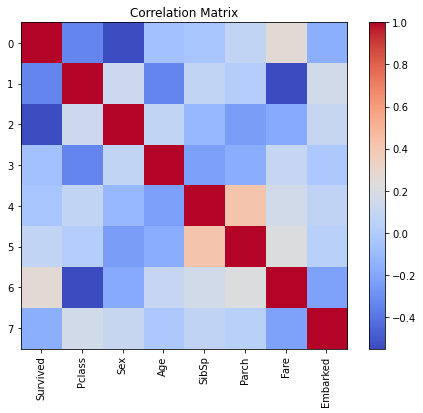

Scaled Features:
[[ 0.82737724  0.73769513 -0.56573646  0.43279337 -0.47367361 -0.50244517
   0.58595414]
 [-1.56610693 -1.35557354  0.66386103  0.43279337 -0.47367361  0.78684529
  -1.9423032 ]
 [ 0.82737724 -1.35557354 -0.25833709 -0.4745452  -0.47367361 -0.48885426
   0.58595414]
 [-1.56610693 -1.35557354  0.4333115   0.43279337 -0.47367361  0.42073024
   0.58595414]
 [ 0.82737724  0.73769513  0.4333115  -0.4745452  -0.47367361 -0.48633742
   0.58595414]]
Training Samples: 712
Testing Samples: 179
Training Completed Successfully.
Predicted Values:
[0 0 0 1 1 1 1 0 1 1 0 0 0 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 0 1 0 1 1 1 0 0 0
 1 1 0 0 0 0 0 1 0 0 0 0 0 1 1 0 0 0 1 0 1 1 1 0 1 1 0 0 1 0 0 0 1 1 1 1 1
 0 0 1 1 1 0 0 1 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 1
 0 1 0 1 0 0 0 1 0 0 1 1 0 0 1 1 1 1 0 1 0 0 1 0 1 1 0 0 1 0 1 0 0 0 1 0 0
 1 0 0 0 0 1 0 0 0 1 1 1 0 0 0 1 0 0 0 1 0 0 1 1 0 1 0 0 0 1 1]

Accuracy= 0.8044692737430168

Confusion Matrix
[[90 15]
 [20 54]]

Classificat

In [49]:
# 1.IMPORT THE LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression 

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# 2.LOAD THE DATASET

df=pd.read_csv(r"C:\Users\user\OneDrive\Titanic-Dataset.csv")  

print(df.head())

# 3.UNDERSTAND THE DATA

print("Shape Of Dataset")
print(df.shape)

print("\nColumn Names")
print(df.columns)

print("\nInformation")
print(df.info())

print("\nStatistical Summary")
print(df.describe())

print("\nMissing values")
print(df.isnull().sum())

# 4.DATA PREPROCESSING 

# Filling Missing Age With Median 
df['Age'].fillna(df['Age'].median(),inplace=True)

# Filling Missing Embarked With MOde
df['Embarked'].fillna(df['Embarked'].mode()[0],inplace=True)

# Drop Cabin Because It Contains Many Missing Values
if 'Cabin' in df.columns:
    df.drop('Cabin',axis=1,inplace=True)
    
# Drop Name,Ticket And PassengerId
drop_columns=['PassengerId','Name','Ticket']
for col in drop_columns:
    if col in df.columns:
        df.drop(col,axis=1,inplace=True)
        
print(df.head())

# 5.CATEGORIAL DATA
print("\n=============LABEL ENCODING==============\n")
encoder=LabelEncoder()
df['Sex']=encoder.fit_transform(df['Sex'])
df['Embarked']=encoder.fit_transform(df['Embarked'])

print(df.head())

# 6.EXPLORATORY DATA ANALYSIS 

print("\n================EDA==================\n")
print(df['Survived'].value_counts())
 
# Survival Count
plt.figure(figsize=(5,4))
df['Survived'].value_counts().plot(kind='bar')
plt.title("Survival Count")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.show()
 
# Age Histogram
plt.figure(figsize=(6,4))
plt.hist(df['Age'],bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# Fare Histogram
plt.figure(figsize=(6,4))
plt.hist(df['Fare'],bins=20)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()

# Correlation Matrix
plt.figure(figsize=(8,6))
plt.imshow(df.corr(),cmap='coolwarm')
plt.colorbar()

plt.xticks(range(len(df.columns)),df.columns,rotation=90)
plt.xticks(range(len(df.columns)),df.columns)

plt.title("Correlation Matrix")
plt.show()

# 7.SCALING

X=df.drop("Survived",axis=1)
y=df["Survived"]

scaler=StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled Features:")
print(X_scaled[:5])

# 8.SPLIT THE DATA
X_train,X_test,y_train,y_test=train_test_split(X_scaled,y,test_size=0.20,random_state=42)

print("Training Samples:",len(X_train))
print("Testing Samples:",len(X_test))

# 9.CHOOSE THE MODEL

model=LogisticRegression()

# 10.TRAIN THE MODEL

model.fit(X_train,y_train)
print("Training Completed Successfully.")

# 11.TEST THE MODEL

y_pred=model.predict(X_test)
print("Predicted Values:")
print(y_pred)

# 12.EVALUATE THE MODEL

accuracy=accuracy_score(y_test,y_pred)
print("\nAccuracy=",accuracy)

print("\nConfusion Matrix")
print(confusion_matrix(y_test,y_pred))


print("\nClassification Report")
print(classification_report(y_test,y_pred))

# 13.PREDICT NEW PASSENGER

# Features :Passenger Class,Sex,Age,SibSp,Parch,Fare,Embarked

new_passenger=[[3,     #Passenger Class
                0,     #Sex
                25,    #Age
                0,     #SibSp
                0,     #Parch
                8.05,  #Fare
                2      #Embarked 
]]
                
new_scaled=scaler.transform(new_passenger)
   
prediction = model.predict(new_scaled)
                
if prediction[0]==1:   
    print("Passenger Will SURVIVE")
else:
    print("Passenger Will Not SURVIVE")
    
accuracy=accuracy_score(y_test,y_pred)
print("\nAccuracy=",accuracy)
                
print("\n============MACHINE LEARNING PIPELINE COMPLETED===============\n")